# MDR-TS v13.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v13.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

This version adds a proper temporal backbone to the model instead of relying only on engineered rolling features. A Kalman-style wetness bucket now tracks rainfall memory over time, and a train-only Gaussian HMM detects hydrologic regimes like dry, transition, and saturated periods. These state and regime signals are added as new features, all generated sequentially per station to preserve strict temporal integrity. The core model itself stays the same, so any performance changes reflect the impact of adding explicit dynamics rather than tweaking the regressor.

## 0. Imports

In [2]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

from xgboost import XGBRegressor

import torch

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [3]:
# Reproducibility
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [4]:
# Project paths
VERSION = "v13.1"
SUBVERSION = "v13.1"
RUN_NAME = "mdr_ts_v13_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v13.1/v13.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [5]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_5.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_5.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_5.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/train_derived_new_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/val_derived_new_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/test_derived_new_updated.csv


In [6]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 356

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'soil_moisture_5cm', 'D_sin_DOY', 'D_cos_DOY', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1']


## 4. Data Sanity Checks

In [7]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

BASE_FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_3d",
  "G_rain_sum_7d",
  "G_rain_sum_30d",
  "G_API",

  "G_DSLR",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_G_API_kobs30",
  "V_rollmax_G_API_kobs7",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmean_G_API_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_G_API_kobs7",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

# New: state backbone features (to be GENERATED sequentially later)
STATE_FEATURE_COLS = [
    "S_bucket",          # hidden wetness state s_t
    "S_bucket_d1",       # delta_s,t (s_t - s_{t-1})
    "S_bucket_ema7",     # short memory summary of s_t
    "S_bucket_ema30",    # longer memory summary of s_t
]

# New: HMM regime features (to be generated later)
HMM_FEATURE_COLS = [
    "H_state",       # most likely regime id
    "H_p0",          # posterior probability of regime 0
    "H_p1",          # posterior probability of regime 1
    "H_p2",          # posterior probability of regime 2 (if n_states=3, else filled with 0)
]

FEATURE_COLS = BASE_FEATURE_COLS + STATE_FEATURE_COLS + HMM_FEATURE_COLS

In [8]:
# Two-phase validation:
# Phase A: required-now columns must exist immediately
# Phase B: state columns allowed to be missing until we generate them

required_now = set(KEEP_META_COLS + BASE_FEATURE_COLS + [TARGET_COL])
state_later = set(STATE_FEATURE_COLS + HMM_FEATURE_COLS)

def _missing(df, cols):
    return sorted(list(set(cols) - set(df.columns)))

missing_train_now = _missing(train_df, required_now)
missing_val_now   = _missing(val_df, required_now)
missing_test_now  = _missing(test_df, required_now)

if missing_train_now or missing_val_now or missing_test_now:
    raise ValueError(
        f"Missing REQUIRED columns (must exist now):\n"
        f"  train: {missing_train_now}\n"
        f"  val:   {missing_val_now}\n"
        f"  test:  {missing_test_now}"
    )

# Phase B: report (no error yet)
missing_train_state = _missing(train_df, state_later)
missing_val_state   = _missing(val_df, state_later)
missing_test_state  = _missing(test_df, state_later)

print("Columns locked (Phase A: baseline OK)")
print("  Base features:", len(BASE_FEATURE_COLS))
print("  State features (to add):", len(STATE_FEATURE_COLS))
print("  HMM features (to add):  ", len(HMM_FEATURE_COLS))
print("  Target:", TARGET_COL)

if missing_train_state or missing_val_state or missing_test_state:
    print("\nNOTE: State features not yet generated (expected at this stage).")
    print("  train missing:", missing_train_state)
    print("  val missing:  ", missing_val_state)
    print("  test missing: ", missing_test_state)

Columns locked (Phase A: baseline OK)
  Base features: 46
  State features (to add): 4
  HMM features (to add):   4
  Target: soil_moisture_5cm

NOTE: State features not yet generated (expected at this stage).
  train missing: ['H_p0', 'H_p1', 'H_p2', 'H_state', 'S_bucket', 'S_bucket_d1', 'S_bucket_ema30', 'S_bucket_ema7']
  val missing:   ['H_p0', 'H_p1', 'H_p2', 'H_state', 'S_bucket', 'S_bucket_d1', 'S_bucket_ema30', 'S_bucket_ema7']
  test missing:  ['H_p0', 'H_p1', 'H_p2', 'H_state', 'S_bucket', 'S_bucket_d1', 'S_bucket_ema30', 'S_bucket_ema7']


In [9]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [10]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [11]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [12]:
RAIN_COL = "precip_mm"
DATE_COL = "date"
STATION_COL = "station_id"

# hyperparams for the bucket (needs tunning)
ALPHA = 0.92   # decay per timestep (daily) | higher = longer memory
BETA  = 1.00   # rain impact scaling

def add_bucket_features(df: pd.DataFrame,
                        alpha: float,
                        beta: float,
                        station_col: str,
                        date_col: str,
                        rain_col: str) -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values([station_col, date_col]).reset_index(drop=True)

    s = np.zeros(len(df), dtype=np.float64)

    for sid, idx in df.groupby(station_col).indices.items():
        idx = np.array(idx, dtype=int)
        prev = 0.0
        for j in idx:
            r = df.at[j, rain_col]
            if pd.isna(r):
                r = 0.0
            prev = alpha * prev + beta * float(r)
            s[j] = prev

    df["S_bucket"] = s
    df["S_bucket_d1"] = df.groupby(station_col)["S_bucket"].diff().fillna(0.0)

    # adjust=False for causal EMA, True for EMA
    df["S_bucket_ema7"]  = df.groupby(station_col)["S_bucket"].transform(lambda x: x.ewm(span=7,  adjust=False).mean())
    df["S_bucket_ema30"] = df.groupby(station_col)["S_bucket"].transform(lambda x: x.ewm(span=30, adjust=False).mean())

    return df

train_df = add_bucket_features(train_df, ALPHA, BETA, STATION_COL, DATE_COL, RAIN_COL)
val_df   = add_bucket_features(val_df,   ALPHA, BETA, STATION_COL, DATE_COL, RAIN_COL)
test_df  = add_bucket_features(test_df,  ALPHA, BETA, STATION_COL, DATE_COL, RAIN_COL)

print("========= bucket features added =========")
print("Train:", train_df[["S_bucket","S_bucket_d1","S_bucket_ema7","S_bucket_ema30"]].describe().T[["mean","std","min","max"]])

========= bucket features added =========
Train:                      mean        std        min         max
S_bucket        53.770934  61.085158   0.000000  481.745777
S_bucket_d1      0.015150   8.660061 -36.139662  120.964430
S_bucket_ema7   53.724601  59.462318   0.000000  426.694174
S_bucket_ema30  53.644737  55.164571   0.000000  369.477385


## 5.1 Regime Features (HMM)

We add *regime* information as causal features.

- **Kalman-style bucket state** (`S_bucket`, etc.) captures continuous wetness memory.
- A **Gaussian HMM** on a small observation set captures discrete regimes (dry, transition, saturated).
- HMM is **fit on TRAIN only** and then applied forward per-station on train/val/test without using any targets.

Outputs added per row:

- `H_state`: most likely regime id
- `H_p0`, `H_p1`, `H_p2`: posterior regime probabilities (if `n_states=2`, `H_p2` is filled with 0)



In [13]:
OBS_COLS = ["S_bucket", "S_bucket_d1", "LST_modis"]  # keep small + stable (maybe: edit)
N_STATES = 3
MAX_TRAIN_POINTS = 80000
EM_ITERS = 15
EPS = 1e-6
SEED = 42

rng = np.random.default_rng(SEED)

def _zscore_fit(X):
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd = np.where(sd < EPS, 1.0, sd)
    return mu, sd

def _zscore_apply(X, mu, sd):
    X = (X - mu) / sd
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def _logsumexp(a, axis=None):
    m = np.max(a, axis=axis, keepdims=True)
    s = np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True)) + m
    return np.squeeze(s, axis=axis)

def _gaussian_logpdf_diag(X, means, vars_):
    # X: (T,D), means: (K,D), vars_: (K,D)
    T, D = X.shape
    K = means.shape[0]
    X2 = X[:, None, :]  # (T,1,D)
    diff2 = (X2 - means[None, :, :]) ** 2
    log_det = np.sum(np.log(vars_), axis=1)  # (K,)
    quad = np.sum(diff2 / vars_[None, :, :], axis=2)  # (T,K)
    const = D * np.log(2.0 * np.pi)
    return -0.5 * (const + log_det[None, :] + quad)

def _forward_backward(logB, logpi, logA):
    # logB: (T,K) emissions log p(x_t | z_t=k)
    T, K = logB.shape
    log_alpha = np.empty((T, K), dtype=np.float64)
    log_beta = np.empty((T, K), dtype=np.float64)

    log_alpha[0] = logpi + logB[0]
    for t in range(1, T):
        # log_alpha[t,k] = logB[t,k] + logsum_j (log_alpha[t-1,j] + logA[j,k])
        tmp = log_alpha[t-1][:, None] + logA  # (K,K)
        log_alpha[t] = logB[t] + _logsumexp(tmp, axis=0)

    log_beta[T-1] = 0.0
    for t in range(T - 2, -1, -1):
        # log_beta[t,j] = logsum_k (logA[j,k] + logB[t+1,k] + log_beta[t+1,k])
        tmp = logA + logB[t+1][None, :] + log_beta[t+1][None, :]  # (K,K)
        log_beta[t] = _logsumexp(tmp, axis=1)

    loglik = _logsumexp(log_alpha[T-1], axis=0)
    log_gamma = log_alpha + log_beta - loglik  # (T,K)
    gamma = np.exp(log_gamma)
    gamma = gamma / np.clip(gamma.sum(axis=1, keepdims=True), EPS, None)

    # xi_t(j,k) proportional to alpha_t(j) A(j,k) B_{t+1}(k) beta_{t+1}(k)
    xi_sum = np.zeros((K, K), dtype=np.float64)
    for t in range(T - 1):
        log_xi = (log_alpha[t][:, None] + logA + logB[t+1][None, :] + log_beta[t+1][None, :] - loglik)
        xi = np.exp(log_xi)
        xi = xi / np.clip(xi.sum(), EPS, None)
        xi_sum += xi

    return loglik, gamma, xi_sum

def fit_gaussian_hmm(seqs, n_states=3, n_iters=10):
    # seqs: list of arrays (T_i, D), already standardized
    D = seqs[0].shape[1]
    K = n_states

    # Init with random points from data
    allX = np.vstack(seqs)
    idx = rng.choice(len(allX), size=K, replace=False)
    means = allX[idx].copy()
    vars_ = np.ones((K, D), dtype=np.float64)

    pi = np.ones(K, dtype=np.float64) / K
    A = np.ones((K, K), dtype=np.float64) / K

    for _ in range(n_iters):
        pi_acc = np.zeros(K)
        A_acc = np.zeros((K, K))
        num = np.zeros((K, D))
        den = np.zeros(K)
        var_num = np.zeros((K, D))
        total_ll = 0.0

        logpi = np.log(np.clip(pi, EPS, None))
        logA = np.log(np.clip(A, EPS, None))

        for X in seqs:
            if len(X) < 2:
                continue
            logB = _gaussian_logpdf_diag(X, means, vars_)
            ll, gamma, xi_sum = _forward_backward(logB, logpi, logA)
            total_ll += float(ll)

            pi_acc += gamma[0]
            A_acc += xi_sum
            den += gamma.sum(axis=0)
            num += gamma.T @ X
            # variance: E[(x-mean)^2]
            for k in range(K):
                diff = X - means[k]
                var_num[k] += (gamma[:, k][:, None] * (diff ** 2)).sum(axis=0)

        # M-step
        pi = pi_acc / np.clip(pi_acc.sum(), EPS, None)
        A = A_acc / np.clip(A_acc.sum(axis=1, keepdims=True), EPS, None)
        means = num / np.clip(den[:, None], EPS, None)
        vars_ = var_num / np.clip(den[:, None], EPS, None)
        vars_ = np.clip(vars_, 1e-3, None)

    return {"pi": pi, "A": A, "means": means, "vars": vars_}

def hmm_posteriors_per_sequence(X, params):
    pi, A, means, vars_ = params["pi"], params["A"], params["means"], params["vars"]
    logpi = np.log(np.clip(pi, EPS, None))
    logA = np.log(np.clip(A, EPS, None))
    logB = _gaussian_logpdf_diag(X, means, vars_)
    _, gamma, _ = _forward_backward(logB, logpi, logA)
    states = gamma.argmax(axis=1)
    return gamma, states

def _build_train_sequences(df, obs_cols, station_col="station_id", date_col="date"):
    df = df.sort_values([station_col, date_col]).reset_index(drop=True)
    seqs = []
    for _, g in df.groupby(station_col):
        X = g[obs_cols].to_numpy(dtype=np.float64)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        seqs.append(X)
    return seqs

def _cap_sequences(seqs, max_points):
    total = sum(len(s) for s in seqs)
    if total <= max_points:
        return seqs
    # downsample each sequence proportionally
    ratio = max_points / total
    capped = []
    for X in seqs:
        if len(X) <= 5:
            capped.append(X)
            continue
        keep = max(5, int(len(X) * ratio))
        idx = np.linspace(0, len(X) - 1, keep).astype(int)
        capped.append(X[idx])
    return capped

missing_obs = [c for c in OBS_COLS if c not in train_df.columns]
if missing_obs:
    raise ValueError(f"Missing OBS_COLS in train_df: {missing_obs}. Make sure bucket features ran and LST_modis exists (or edit OBS_COLS).")

train_seqs = _build_train_sequences(train_df, OBS_COLS, station_col=STATION_COL, date_col=DATE_COL)
train_seqs = _cap_sequences(train_seqs, MAX_TRAIN_POINTS)

all_train_X = np.vstack(train_seqs)
mu, sd = _zscore_fit(all_train_X)
train_seqs_std = [_zscore_apply(X, mu, sd) for X in train_seqs]

hmm_params = fit_gaussian_hmm(train_seqs_std, n_states=N_STATES, n_iters=EM_ITERS)
print("HMM fit complete.")
print("pi:", np.round(hmm_params["pi"], 3))
print("A row0:", np.round(hmm_params["A"][0], 3))

def add_hmm_features(df, params, mu, sd, obs_cols, n_states=3,
                     station_col="station_id", date_col="date"):
    df = df.copy()
    df = df.sort_values([station_col, date_col]).reset_index(drop=True)

    # allocate
    T = len(df)
    H_state = np.zeros(T, dtype=np.int64)
    H_p = np.zeros((T, 3), dtype=np.float64)

    for sid, idx in df.groupby(station_col).indices.items():
        idx = np.array(idx, dtype=int)
        X = df.loc[idx, obs_cols].to_numpy(dtype=np.float64)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = _zscore_apply(X, mu, sd)

        gamma, states = hmm_posteriors_per_sequence(X, params)
        H_state[idx] = states
        # gamma shape (len, K)
        for k in range(min(n_states, 3)):
            H_p[idx, k] = gamma[:, k]

    df["H_state"] = H_state.astype(np.int64)
    df["H_p0"] = H_p[:, 0]
    df["H_p1"] = H_p[:, 1]
    df["H_p2"] = H_p[:, 2] if n_states >= 3 else 0.0
    return df

train_df = add_hmm_features(train_df, hmm_params, mu, sd, OBS_COLS, n_states=N_STATES,
                            station_col=STATION_COL, date_col=DATE_COL)
val_df   = add_hmm_features(val_df,   hmm_params, mu, sd, OBS_COLS, n_states=N_STATES,
                            station_col=STATION_COL, date_col=DATE_COL)
test_df  = add_hmm_features(test_df,  hmm_params, mu, sd, OBS_COLS, n_states=N_STATES,
                            station_col=STATION_COL, date_col=DATE_COL)

print("Added HMM features to all splits.")
print(train_df[["H_state","H_p0","H_p1","H_p2"]].head())


HMM fit complete.
pi: [1. 0. 0.]
A row0: [0.934 0.001 0.065]
Added HMM features to all splits.
   H_state           H_p0          H_p1          H_p2
0        0   9.999991e-01  3.028548e-09  8.537047e-07
1        2   1.955524e-04  1.628833e-04  9.996416e-01
2        2   7.029982e-02  2.451247e-03  9.272489e-01
3        2   1.680684e-02  4.610247e-02  9.370907e-01
4        1  2.639630e-150  9.299514e-01  7.004858e-02


### 5.2 Final Column Check (after state + HMM)

In [14]:
# Final column check: ensure all FEATURE_COLS exist now

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])

def _missing(df, cols):
    return sorted(list(set(cols) - set(df.columns)))

missing_train = _missing(train_df, expected)
missing_val   = _missing(val_df, expected)
missing_test  = _missing(test_df, expected)

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns after feature generation:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("All features present. Ready for model definition.")
print("Total features:", len(FEATURE_COLS))


All features present. Ready for model definition.
Total features: 54


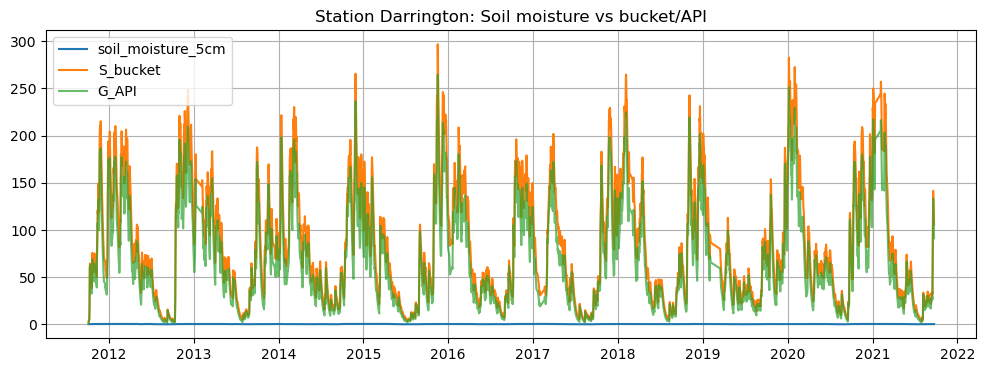

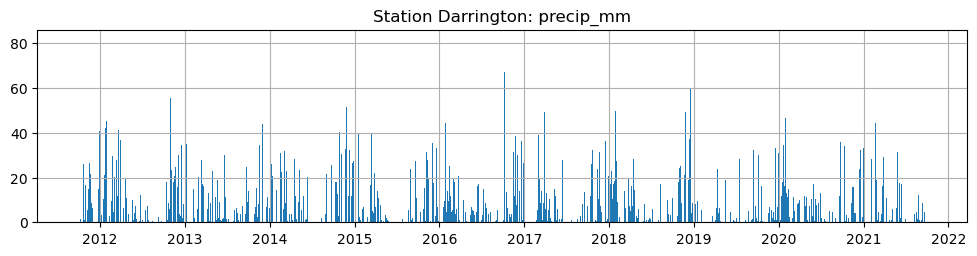

In [15]:
sid = train_df["station_id"].iloc[0]  # darrington
g = train_df[train_df["station_id"] == sid].sort_values("date")

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(g["date"], g["soil_moisture_5cm"], label="soil_moisture_5cm")
ax1.plot(g["date"], g["S_bucket"], label="S_bucket")
ax1.plot(g["date"], g["G_API"], label="G_API", alpha=0.7)
ax1.set_title(f"Station {sid}: Soil moisture vs bucket/API")
ax1.legend()
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 2.5))
ax2.bar(g["date"], g["precip_mm"], width=1.0)
ax2.set_title(f"Station {sid}: precip_mm")
plt.show()

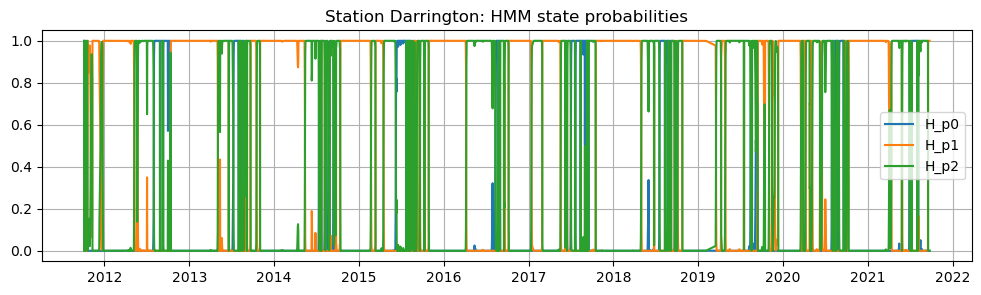

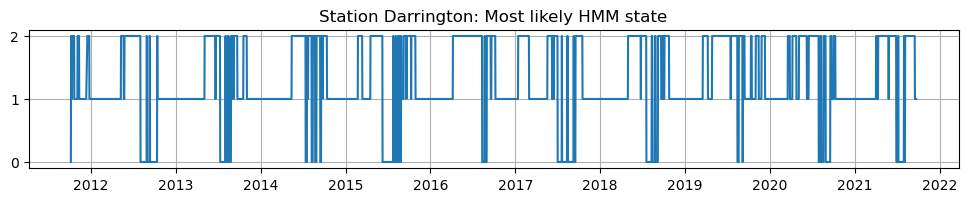

In [16]:
sid = train_df["station_id"].iloc[0] # darrington
g = train_df[train_df["station_id"] == sid].sort_values("date")

plt.figure(figsize=(12, 3))
plt.plot(g["date"], g["H_p0"], label="H_p0")
plt.plot(g["date"], g["H_p1"], label="H_p1")
plt.plot(g["date"], g["H_p2"], label="H_p2")
plt.title(f"Station {sid}: HMM state probabilities")
plt.legend()
plt.show()

plt.figure(figsize=(12, 1.8))
plt.plot(g["date"], g["H_state"], label="H_state")
plt.title(f"Station {sid}: Most likely HMM state")
plt.yticks([0,1,2])
plt.show()

## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [17]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (16972, 54)
  X_val:   (2919, 54)
  X_test:  (2829, 54)
  y_train: (16972,)


### 6.2 Feature Overview

In [18]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
G_rain_sum_30d,1.297717e+02,146.101615,0.000000e+00,1100.500000
DOY,1.856803e+02,102.681888,1.000000e+00,366.000000
V_rollmax_G_API_kobs30,7.421912e+01,72.224672,2.255304e-01,408.757381
S_bucket,5.377093e+01,61.085158,0.000000e+00,481.745777
V_rollmax_G_API_kobs7,5.376347e+01,59.531471,2.220958e-02,408.757381
S_bucket_ema7,5.372460e+01,59.462318,0.000000e+00,426.694174
S_bucket_ema30,5.364474e+01,55.164571,0.000000e+00,369.477385
G_API,4.304036e+01,50.740737,0.000000e+00,408.757381
G_rain_sum_7d,3.423221e+01,48.772041,0.000000e+00,477.000000
V_rollmean_G_API_kobs30,4.318955e+01,45.947859,7.532330e-02,313.507425


### 6.3 Feature Correlation

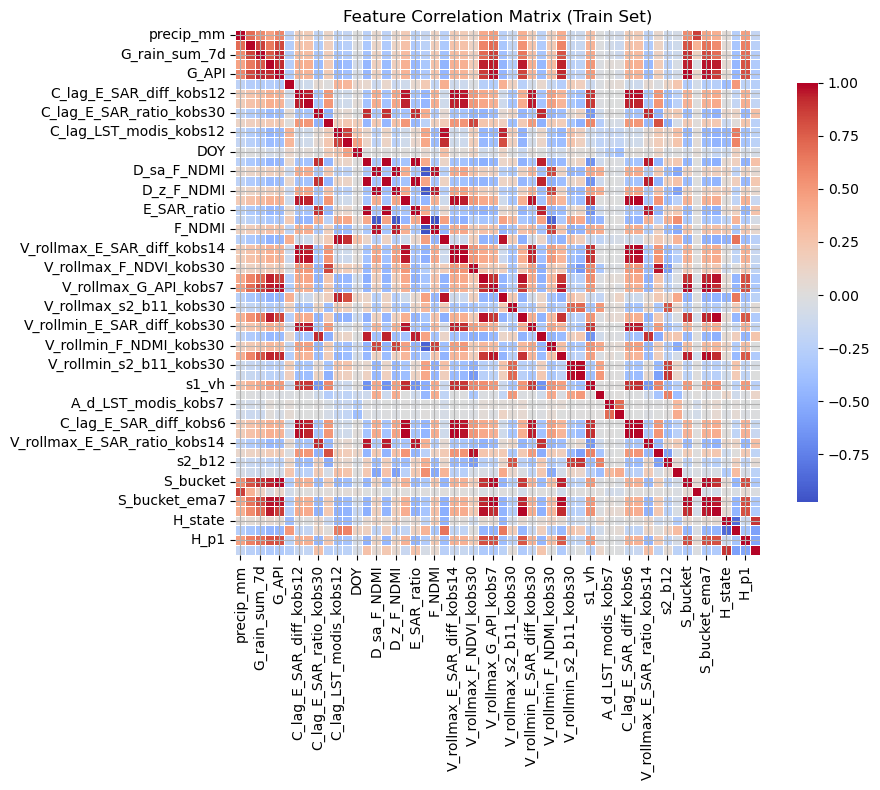

In [19]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [20]:
def make_quantile_weights(y, q):
    # q in {0.2, 0.5, 0.8}
    # emphasize points above/below the q-quantile

    y = np.asarray(y)
    thresh = np.quantile(y, q)
    if q < 0.5:
        w = np.where(y <= thresh, 2.0, 1.0)
    elif q > 0.5:
        w = np.where(y >= thresh, 2.0, 1.0)
    else:
        w = np.ones_like(y, dtype=float)
    return w

In [21]:
X_tv = pd.concat([X_train, X_val], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

test_fold = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
ps = PredefinedSplit(test_fold=test_fold)

# scorers
def neg_mae_scorer(estimator, X, y):
    yhat = estimator.predict(X)
    return -mean_absolute_error(y, yhat)

def neg_rmse_scorer(estimator, X, y):
    yhat = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y, yhat))

SCORER = neg_mae_scorer

base_model = XGBRegressor(
    objective="reg:pseudohubererror",
    eval_metric="rmse",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
)

param_dist_xgb = {
    "n_estimators": [800, 1200, 1600],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "min_child_weight": [3, 5, 8, 12],
    "gamma": [0.0, 0.1, 0.3, 0.5, 1.0],
    "subsample": [0.6, 0.75, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "reg_alpha": [0.0, 0.01, 0.05, 0.1],
    "reg_lambda": [1.0, 2.0, 3.0, 5.0],
}

fit_kwargs = dict(
    eval_set=[(X_val, y_val)],
    verbose=False,
)

quantiles = [0.2, 0.5, 0.8]
expert_models = {}
expert_preds = {}

for q in quantiles:
    w_train = make_quantile_weights(y_train, q)
    w_val   = make_quantile_weights(y_val, q)
    w_tv = np.r_[w_train, w_val]

    search_xgb = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist_xgb,
        n_iter=DEEP_SEARCH,
        scoring=SCORER,
        cv=ps,
        verbose=2,
        random_state=SEED,
        n_jobs=-1,
    )

    print(f"\n=== Searching XGB expert for q={q} (weighted) ===")
    search_xgb.fit(X_tv, y_tv, sample_weight=w_tv, **fit_kwargs)

    best = search_xgb.best_estimator_
    expert_models[q] = best

    print(f"Best params for q={q}:")
    for k, v in search_xgb.best_params_.items():
        print(f"  {k}: {v}")
    print("Best VAL score (neg):", float(search_xgb.best_score_))

    # Fit final on train with weights (keep val untouched for eval)
    best.fit(X_train, y_train, sample_weight=w_train, **fit_kwargs)

    expert_preds[q] = {
        "train": best.predict(X_train),
        "val":   best.predict(X_val),
        "test":  best.predict(X_test),
    }

print("\nQuantile-ish XGB experts trained.")
print("Available experts:", sorted(expert_models.keys()))
print("Pred shapes (q=0.5):", {k: v.shape for k, v in expert_preds[0.5].items()})


=== Searching XGB expert for q=0.2 (weighted) ===
Fitting 1 folds for each of 40 candidates, totalling 40 fits
[CV] END colsample_bytree=0.75, gamma=0.3, learning_rate=0.05, max_depth=6, min_child_weight=12, n_estimators=800, reg_alpha=0.05, reg_lambda=2.0, subsample=0.9; total time=   2.4s
[CV] END colsample_bytree=0.75, gamma=0.5, learning_rate=0.03, max_depth=4, min_child_weight=12, n_estimators=800, reg_alpha=0.01, reg_lambda=5.0, subsample=0.6; total time=   2.4s
[CV] END colsample_bytree=0.75, gamma=0.3, learning_rate=0.01, max_depth=6, min_child_weight=8, n_estimators=800, reg_alpha=0.1, reg_lambda=5.0, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=0.75, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=1200, reg_alpha=0.0, reg_lambda=2.0, subsample=1.0; total time=   3.3s
[CV] END colsample_bytree=0.75, gamma=1.0, learning_rate=0.03, max_depth=4, min_child_weight=3, n_estimators=1600, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total 

```yaml
Best XGB params:
  subsample: 0.6
  reg_lambda: 5.0
  reg_alpha: 0.01
  n_estimators: 8000
  min_child_weight: 5
  max_depth: 6
  learning_rate: 0.01
  gamma: 0.0
  colsample_bytree: 0.6
Best VAL RMSE: 0.04560946274046915
```
```yaml
Best params for q=0.2:
  subsample: 1.0
  reg_lambda: 3.0
  reg_alpha: 0.1
  n_estimators: 800
  min_child_weight: 8
  max_depth: 6
  learning_rate: 0.01
  gamma: 0.0
  colsample_bytree: 0.6
Best VAL score (neg): -0.035509706012258876
```

```yaml
Best params for q=0.5:
  subsample: 0.75
  reg_lambda: 1.0
  reg_alpha: 0.0
  n_estimators: 1200
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.3
  colsample_bytree: 1.0
Best VAL score (neg): -0.03508385389785973
```

```yaml
Best params for q=0.8:
  subsample: 1.0
  reg_lambda: 3.0
  reg_alpha: 0.05
  n_estimators: 1200
  min_child_weight: 8
  max_depth: 5
  learning_rate: 0.03
  gamma: 0.3
  colsample_bytree: 0.9
Best VAL score (neg): -0.031967109846656315
```

In [22]:
final_fit_kwargs = dict(
    eval_set=[(X_val, y_val)],
    verbose=200,
)

expert_preds = {}

for q, m in expert_models.items():
    w_train = make_quantile_weights(y_train, q)

    m.fit(X_train, y_train, sample_weight=w_train, **final_fit_kwargs)

    expert_preds[q] = {
        "train": m.predict(X_train),
        "val":   m.predict(X_val),
        "test":  m.predict(X_test),
    }

    print(f"\nExpert q={q} predictions generated")
    print("  yhat_train:", expert_preds[q]["train"].shape)
    print("  yhat_val:  ", expert_preds[q]["val"].shape)
    print("  yhat_test: ", expert_preds[q]["test"].shape)

[0]	validation_0-rmse:0.11024
[200]	validation_0-rmse:0.05044
[400]	validation_0-rmse:0.04739
[600]	validation_0-rmse:0.04696
[799]	validation_0-rmse:0.04712

Expert q=0.2 predictions generated
  yhat_train: (16972,)
  yhat_val:   (2919,)
  yhat_test:  (2829,)
[0]	validation_0-rmse:0.09988
[200]	validation_0-rmse:0.04653
[400]	validation_0-rmse:0.04654
[600]	validation_0-rmse:0.04654
[799]	validation_0-rmse:0.04654

Expert q=0.5 predictions generated
  yhat_train: (16972,)
  yhat_val:   (2919,)
  yhat_test:  (2829,)
[0]	validation_0-rmse:0.10007
[200]	validation_0-rmse:0.04390
[400]	validation_0-rmse:0.04295
[600]	validation_0-rmse:0.04301
[799]	validation_0-rmse:0.04301

Expert q=0.8 predictions generated
  yhat_train: (16972,)
  yhat_val:   (2919,)
  yhat_test:  (2829,)


## 7. Training Loop

In [23]:
X_tv = pd.concat([X_train, X_val], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

test_fold = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
ps = PredefinedSplit(test_fold=test_fold)

def neg_rmse_scorer(estimator, X, y):
    yhat = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y, yhat))

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_jobs=-1,
        random_state=SEED,
        warm_start=False,
        bootstrap=True,
        oob_score=True,
    )),
])

param_dist_rf = {
    "model__n_estimators": [800, 1200, 1600, 2400],
    "model__max_depth": [12, 16, 20, 24, None],
    "model__max_leaf_nodes": [None, 128, 256, 512, 1024],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10, 20, 50],
    "model__min_impurity_decrease": [0.0, 1e-5, 1e-4, 1e-3],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "model__max_samples": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

search_rf = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist_rf,
    n_iter=DEEP_SEARCH,
    scoring=neg_rmse_scorer,
    cv=ps,
    verbose=2,
    random_state=SEED,
    n_jobs=-1,
    error_score="raise",
)

search_rf.fit(X_tv, y_tv)

model_rf = search_rf.best_estimator_

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "max_leaf_nodes": model_rf.named_steps["model"].max_leaf_nodes,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "min_impurity_decrease": model_rf.named_steps["model"].min_impurity_decrease,
    "max_features": model_rf.named_steps["model"].max_features,
    "bootstrap": model_rf.named_steps["model"].bootstrap,
    "max_samples": model_rf.named_steps["model"].max_samples,
    "oob_score": model_rf.named_steps["model"].oob_score,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
}

print("\nBest RF params:")
for k, v in search_rf.best_params_.items():
    print(f"  {k}: {v}")
print("Best VAL RMSE:", float(-search_rf.best_score_))

Fitting 1 folds for each of 40 candidates, totalling 40 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__max_leaf_nodes=1024, model__max_samples=1.0, model__min_impurity_decrease=0.001, model__min_samples_leaf=2, model__min_samples_split=20, model__n_estimators=800; total time=  16.3s
[CV] END model__max_depth=None, model__max_features=log2, model__max_leaf_nodes=256, model__max_samples=1.0, model__min_impurity_decrease=0.001, model__min_samples_leaf=10, model__min_samples_split=50, model__n_estimators=1600; total time=  27.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__max_leaf_nodes=None, model__max_samples=0.9, model__min_impurity_decrease=0.001, model__min_samples_leaf=5, model__min_samples_split=50, model__n_estimators=1600; total time=  30.8s
[CV] END model__max_depth=24, model__max_features=0.3, model__max_leaf_nodes=128, model__max_samples=0.8, model__min_impurity_decrease=0.0001, model__min_samples_leaf=20, model__min_samples_split=20, mod

```yaml
Best RF params:
  model__n_estimators: 800
  model__min_samples_split: 50
  model__min_samples_leaf: 10
  model__min_impurity_decrease: 1e-05
  model__max_samples: 0.6
  model__max_leaf_nodes: 1024
  model__max_features: 0.3
  model__max_depth: 24
Best VAL RMSE: 0.046233608989764585
```

In [40]:
yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)


RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)


In [41]:
y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

def _summ(name, y_true, y_pred):
    y_pred = np.asarray(y_pred).ravel()
    r2 = float(r2_score(y_true, y_pred))
    bias = float(np.mean(y_true - y_pred))
    print(f"{name:>10s} | R2={r2:.6f} | bias(true-pred)={bias:.6f}")

print("\n=== XGB quantile-ish experts (unstacked) ===")
for q in sorted(expert_preds.keys()):
    _summ(f"q={q}", y_val_np,  expert_preds[q]["val"])
for q in sorted(expert_preds.keys()):
    _summ(f"q={q}", y_test_np, expert_preds[q]["test"])

avg_val  = np.mean([expert_preds[q]["val"]  for q in sorted(expert_preds.keys())], axis=0)
avg_test = np.mean([expert_preds[q]["test"] for q in sorted(expert_preds.keys())], axis=0)

print("\n=== Simple average of experts ===")
_summ("avg(val)",  y_val_np,  avg_val)
_summ("avg(test)", y_test_np, avg_test)


=== XGB quantile-ish experts (unstacked) ===
     q=0.2 | R2=0.781081 | bias(true-pred)=0.023655
     q=0.5 | R2=0.786517 | bias(true-pred)=0.022329
     q=0.8 | R2=0.817605 | bias(true-pred)=0.015941
     q=0.2 | R2=0.704232 | bias(true-pred)=0.019466
     q=0.5 | R2=0.736503 | bias(true-pred)=0.015374
     q=0.8 | R2=0.757780 | bias(true-pred)=0.007403

=== Simple average of experts ===
  avg(val) | R2=0.802542 | bias(true-pred)=0.020642
 avg(test) | R2=0.742589 | bias(true-pred)=0.014081


In [42]:
alphas = np.logspace(-6, 3, 15)
best = None

Q = sorted(expert_preds.keys())  # [0.2, 0.5, 0.8]
Z_val  = np.column_stack([np.asarray(expert_preds[q]["val"]).ravel()  for q in Q])
Z_test = np.column_stack([np.asarray(expert_preds[q]["test"]).ravel() for q in Q])

for a in alphas:
    meta = Ridge(alpha=a)
    meta.fit(Z_val, y_val_np)

    yhat_val_meta = meta.predict(Z_val)
    r2_val = r2_score(y_val_np, yhat_val_meta)

    if (best is None) or (r2_val > best["r2_val"]):
        best = {
            "alpha": float(a),
            "r2_val": float(r2_val),
            "coef": meta.coef_.astype(float),
            "intercept": float(meta.intercept_),
        }

print("Best Ridge stack (selected on VAL):")
print("  alpha     =", best["alpha"])
print("  weights   =", best["coef"])
print("  intercept =", best["intercept"])
print("  val R2    =", best["r2_val"])

meta = Ridge(alpha=best["alpha"])
meta.fit(Z_val, y_val_np)

yhat_test_meta = meta.predict(Z_test)
print("\nSTACKED (3 experts -> Ridge) TEST R2:", float(r2_score(y_test_np, yhat_test_meta)))
print("STACKED TEST bias (true-pred):", float(np.mean(y_test_np - yhat_test_meta)))

Best Ridge stack (selected on VAL):
  alpha     = 4.393970560760795e-06
  weights   = [ 0.79248488 -0.68538773  0.86326456]
  intercept = 0.023741871118545532
  val R2    = 0.8498008218530172

STACKED (3 experts -> Ridge) TEST R2: 0.7544924824594562
STACKED TEST bias (true-pred): -0.006043785575718035


In [43]:
Q = sorted(expert_preds.keys())  # [0.2, 0.5, 0.8]

Z_train = np.column_stack([np.asarray(expert_preds[q]["train"]).ravel() for q in Q])
Z_val   = np.column_stack([np.asarray(expert_preds[q]["val"]).ravel()   for q in Q])
Z_test  = np.column_stack([np.asarray(expert_preds[q]["test"]).ravel()  for q in Q])

meta = Ridge(alpha=best["alpha"])
meta.fit(Z_val, y_val_np)

yhat_train_cal = meta.predict(Z_train)
yhat_val_cal   = meta.predict(Z_val)
yhat_test_cal  = meta.predict(Z_test)

### 7.2 Metrics

In [44]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def metrics_block(name, y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

Q = sorted(expert_preds.keys())  # [0.2, 0.5, 0.8]

rows_before = []
for q in Q:
    rows_before += [
        {"model": f"xgb_q{q}_", **metrics_block("train", y_train_np, expert_preds[q]["train"])},
        {"model": f"xgb_q{q}_", **metrics_block("val",   y_val_np,   expert_preds[q]["val"])},
        {"model": f"xgb_q{q}_", **metrics_block("test",  y_test_np,  expert_preds[q]["test"])},
    ]

avg_train = np.mean([expert_preds[q]["train"] for q in Q], axis=0)
avg_val   = np.mean([expert_preds[q]["val"]   for q in Q], axis=0)
avg_test  = np.mean([expert_preds[q]["test"]  for q in Q], axis=0)

rows_before += [
    {"model": "xgb_avg", **metrics_block("train", y_train_np, avg_train)},
    {"model": "xgb_avg", **metrics_block("val",   y_val_np,   avg_val)},
    {"model": "xgb_avg", **metrics_block("test",  y_test_np,  avg_test)},
]

results_before = pd.DataFrame(rows_before)

results_after = pd.DataFrame([
    {"model": "ridge_stack", **metrics_block("train", y_train_np, yhat_train_cal)},
    {"model": "ridge_stack", **metrics_block("val",   y_val_np,   yhat_val_cal)},
    {"model": "ridge_stack", **metrics_block("test",  y_test_np,  yhat_test_cal)},
])

print("BEFORE (experts + avg):")
display(results_before)

print("\nAFTER (Ridge stacked):")
display(results_after)

BEFORE (experts + avg):


,model,split,MAE,RMSE,R2,bias_mean(true-pred)
0,xgb_q0.2_,train,0.014961,0.021418,0.956127,0.000939
1,xgb_q0.2_,val,0.035399,0.047125,0.781081,0.023655
2,xgb_q0.2_,test,0.038544,0.050866,0.704232,0.019466
3,xgb_q0.5_,train,0.024010,0.031761,0.903523,-0.000003
4,xgb_q0.5_,val,0.034855,0.046536,0.786517,0.022329
5,xgb_q0.5_,test,0.036817,0.048011,0.736503,0.015374
6,xgb_q0.8_,train,0.030553,0.039580,0.850173,-0.006042
7,xgb_q0.8_,val,0.032027,0.043014,0.817605,0.015941
8,xgb_q0.8_,test,0.034775,0.046031,0.757780,0.007403
9,xgb_avg,train,0.022570,0.029890,0.914554,-0.001702



AFTER (Ridge stacked):


,model,split,MAE,RMSE,R2,bias_mean(true-pred)
0,ridge_stack,train,0.029755,0.036814,0.870384,-2.243557e-02
1,ridge_stack,val,0.029957,0.039034,0.849801,-2.887170e-07
2,ridge_stack,test,0.034997,0.046343,0.754492,-6.043786e-03


In [45]:
Q = sorted(expert_preds.keys())  # [0.2, 0.5, 0.8]

meta_val = np.column_stack(
    [np.asarray(expert_preds[q]["val"]).ravel() for q in Q] +
    [np.asarray(yhat_val_rf).ravel()]
)

meta_test = np.column_stack(
    [np.asarray(expert_preds[q]["test"]).ravel() for q in Q] +
    [np.asarray(yhat_test_rf).ravel()]
)

meta = Ridge(alpha=1.0)
meta.fit(meta_val, y_val_np)

yhat_test_stack = meta.predict(meta_test)

print("STACKED (q20+q50+q80 + RF -> Ridge) test metrics:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack)))
print("  weights:", meta.coef_, "intercept:", float(meta.intercept_))
print("  weight order: [q0.2, q0.5, q0.8, RF]")

STACKED (q20+q50+q80 + RF -> Ridge) test metrics:
  R2  : 0.7763221965968382
  MAE : 0.03311254843627441
  RMSE: 0.0442343514450669
  bias: -0.0035847201339627476
  weights: [ 0.13335852 -0.00172454  0.07265753  0.78124608] intercept: 0.016255830735422278
  weight order: [q0.2, q0.5, q0.8, RF]


In [46]:
meta_val2  = np.column_stack([yhat_val_cal,  np.asarray(yhat_val_rf).ravel()])
meta_test2 = np.column_stack([yhat_test_cal, np.asarray(yhat_test_rf).ravel()])

meta2 = Ridge(alpha=1.0)
meta2.fit(meta_val2, y_val_np)

yhat_test_stack2 = meta2.predict(meta_test2)

print("\nSTACKED using calibrated XGB preds:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack2)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack2)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack2))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack2)))
print("  weights:", meta2.coef_, "intercept:", float(meta2.intercept_))


STACKED using calibrated XGB preds:
  R2  : 0.7763105757874812
  MAE : 0.03306422372298207
  RMSE: 0.044235500491331244
  bias: -0.0036070780067996543
  weights: [0.19052393 0.79858862] intercept: 0.011387997862032567


### 7.3 Diagnostics

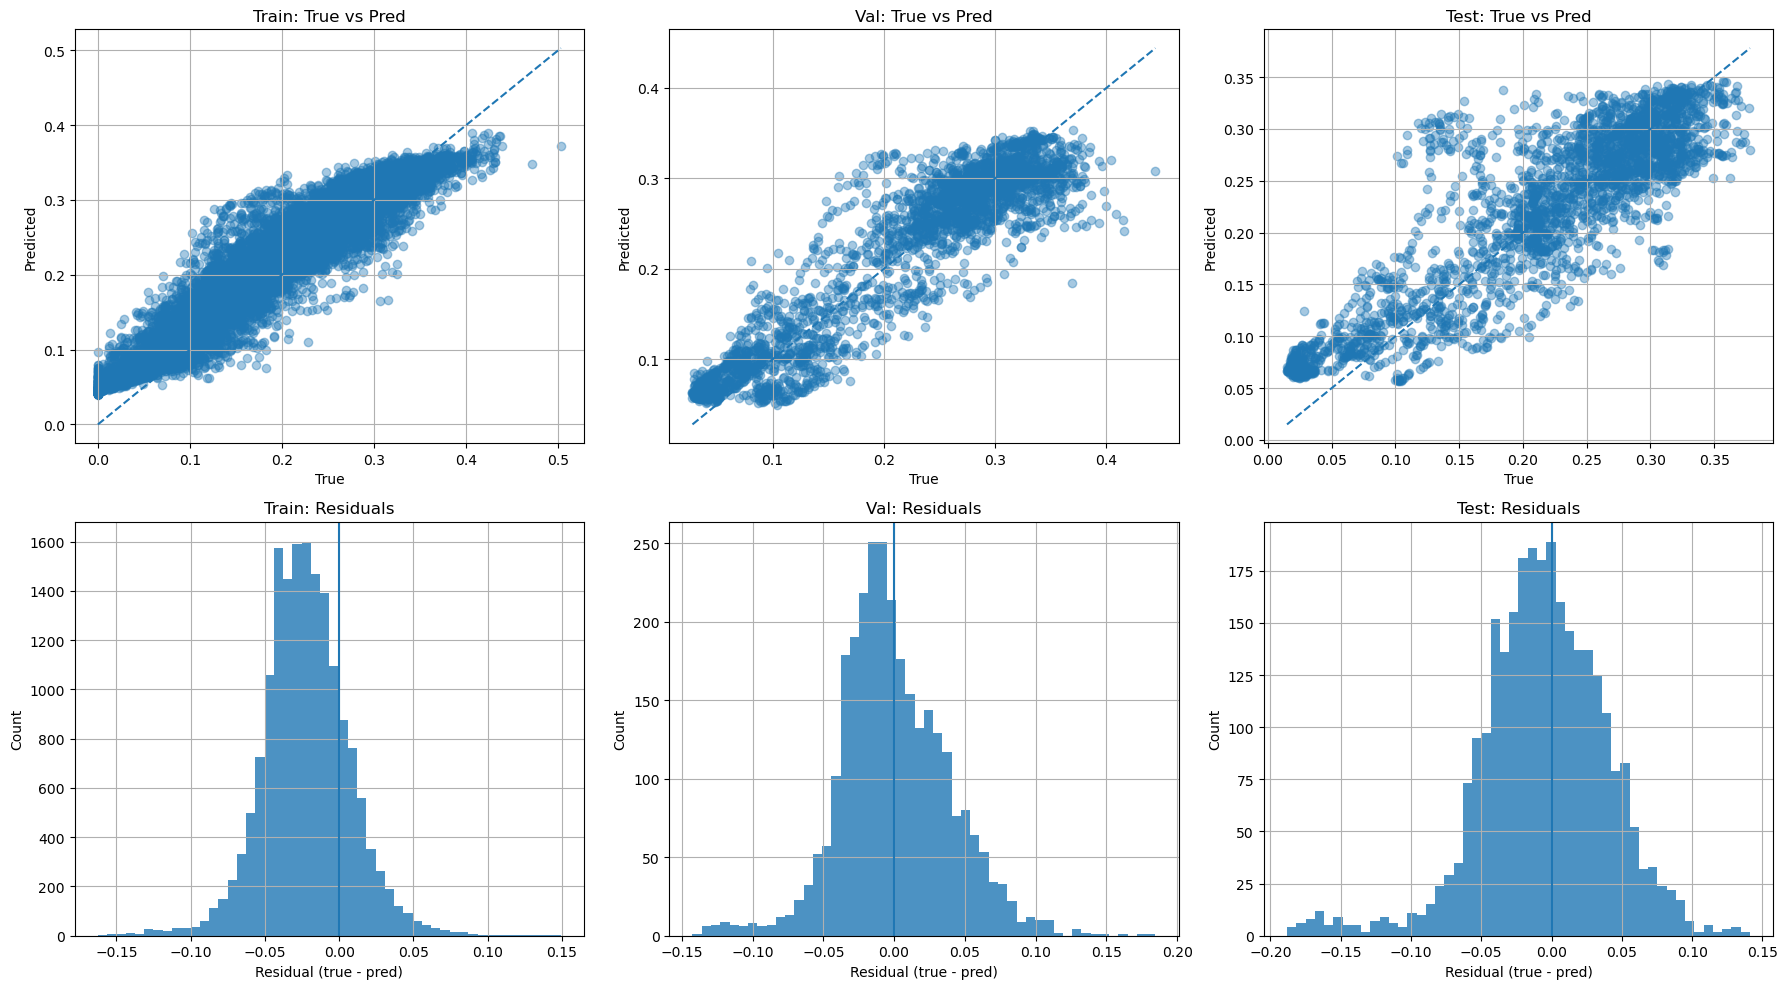

In [47]:
def scatter_plot(ax, y_true, y_pred, title):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    ax.scatter(y_true, y_pred, alpha=0.4)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    resid = y_true - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0)
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

yhat_train_final = yhat_train_cal
yhat_val_final   = yhat_val_cal
yhat_test_final  = yhat_test_cal

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train_final, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_final,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_final,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train_final, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_final,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_final,  "Test: Residuals")

plt.tight_layout()
plt.show()

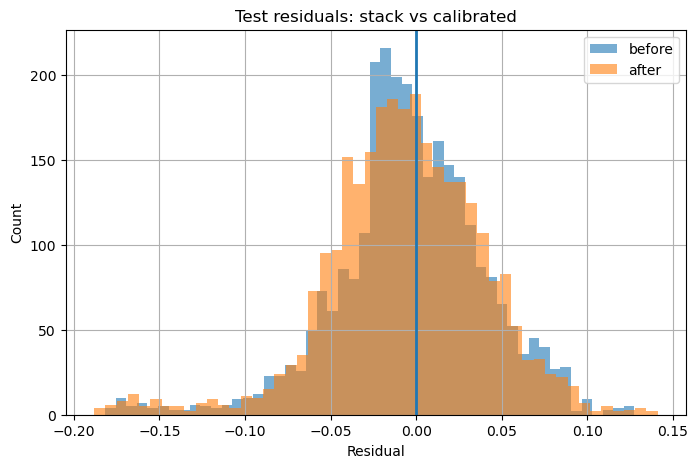

In [48]:
res_before = y_test - yhat_test_stack
res_after  = y_test - yhat_test_cal

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals: stack vs calibrated")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7.4 Feature Importance

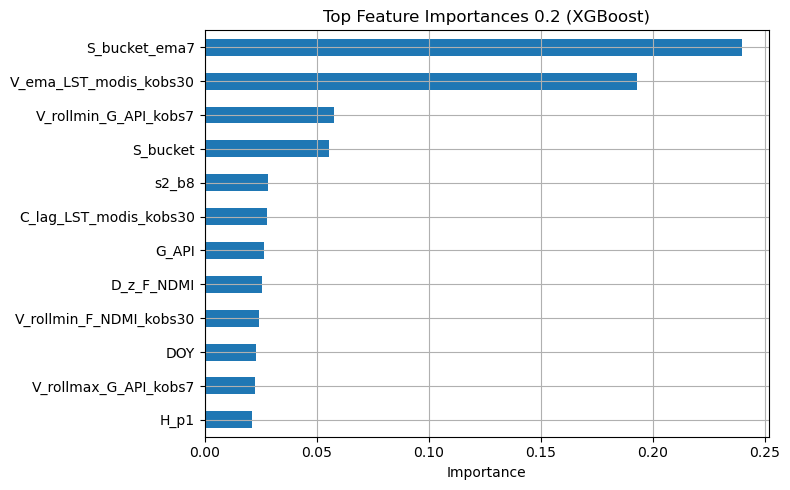

S_bucket_ema7                   0.239811
V_ema_LST_modis_kobs30          0.193028
V_rollmin_G_API_kobs7           0.057615
S_bucket                        0.055385
s2_b8                           0.028032
C_lag_LST_modis_kobs30          0.027626
G_API                           0.026422
D_z_F_NDMI                      0.025637
V_rollmin_F_NDMI_kobs30         0.024439
DOY                             0.022813
V_rollmax_G_API_kobs7           0.022464
H_p1                            0.020908
D_sa_F_NDMI                     0.019991
C_lag_LST_modis_kobs12          0.012522
G_rain_sum_30d                  0.012340
V_rollmin_E_SAR_diff_kobs30     0.011346
F_MSI                           0.010595
S_bucket_ema30                  0.009146
G_rain_sum_7d                   0.008725
D_z_E_SAR_ratio                 0.007917
V_rollmax_E_SAR_ratio_kobs14    0.007847
G_rain_sum_3d                   0.007723
F_NDMI                          0.007710
D_sa_E_SAR_ratio                0.007460
V_rollmax_E_SAR_

In [49]:
importances_xgb = pd.Series(expert_models[0.2].feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances_xgb.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances 0.2 (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances_xgb

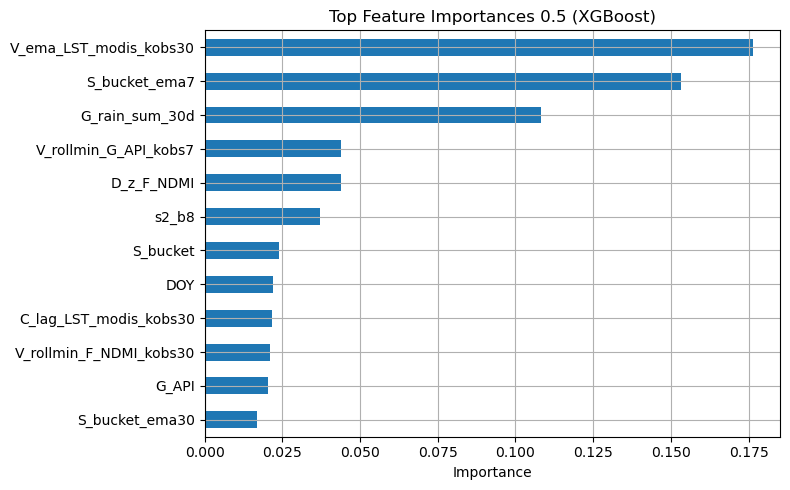

V_ema_LST_modis_kobs30          0.176295
S_bucket_ema7                   0.153356
G_rain_sum_30d                  0.108288
V_rollmin_G_API_kobs7           0.044000
D_z_F_NDMI                      0.043726
s2_b8                           0.036983
S_bucket                        0.023809
DOY                             0.021990
C_lag_LST_modis_kobs30          0.021775
V_rollmin_F_NDMI_kobs30         0.021035
G_API                           0.020207
S_bucket_ema30                  0.016926
H_p1                            0.016706
V_rollmax_E_SAR_diff_kobs14     0.012981
D_z_E_SAR_ratio                 0.012937
V_rollmax_G_API_kobs7           0.011925
D_sa_F_NDMI                     0.011741
E_SAR_ratio                     0.010568
V_rollmin_E_SAR_ratio_kobs30    0.010268
C_lag_E_SAR_diff_kobs30         0.010252
C_lag_LST_modis_kobs12          0.010191
E_SAR_diff                      0.009626
V_rollmin_E_SAR_diff_kobs30     0.009527
D_sa_E_SAR_ratio                0.009446
G_rain_sum_7d   

In [50]:
importances_xgb = pd.Series(expert_models[0.5].feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances_xgb.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances 0.5 (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances_xgb

## 8. Evaluation

### 8.1 Test Metrics

In [51]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.034997,0.046343,0.754492,2829


### 8.2 Test Prediction Scatter

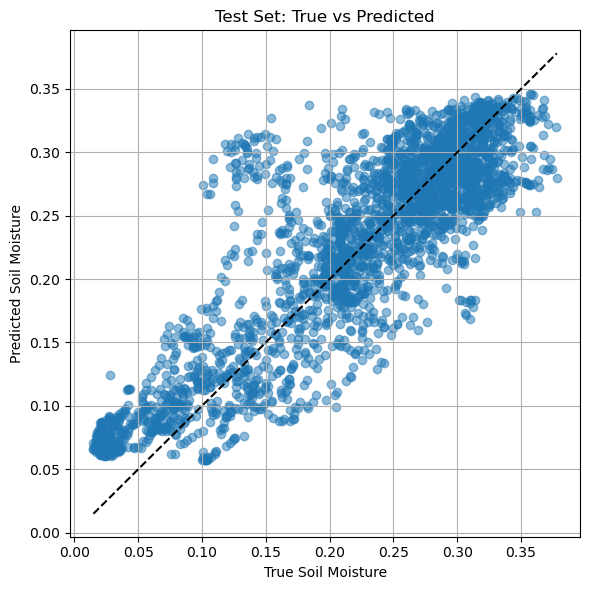

In [52]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [53]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean : -0.000000
TEST residual mean : -0.006044

Prediction ranges
-----------------
VAL  range :  0.049884 to  0.353572
TEST range :  0.057051 to  0.346169



## 9. Save Artifacts

In [38]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v13.1/v13.1/mdr_ts_v13_1_20260217_170502


In [39]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

NameError: name 'model' is not defined

In [ ]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG_FINAL,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/run_metadata.json


In [ ]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results_after.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/metrics.csv


In [ ]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/feature_importance.csv


In [ ]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

---

_Jakob Balkovec_